# 01 — FISTA + Wavelet (Jacopo)
Self-contained: preamble rebuilds the base from the Drive zip, then the method.

In [1]:
# --- Setup (run each session) ---
!pip -q install PyWavelets scikit-image numpy scipy matplotlib pandas pillow

In [2]:
# ================= COMMON PREAMBLE (identical in 00/01/02) =================
# Drive holds ONLY the dataset zip. Each notebook is self-contained:
# mount -> unzip -> load/split -> define Forward, metrics, degrade_det.
from google.colab import drive
drive.mount("/content/drive")

import os, glob, zipfile, numpy as np
from PIL import Image
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.metrics import peak_signal_noise_ratio as _psnr, structural_similarity as _ssim

# ---- EDIT only these ----
DRIVE = "/content/drive/MyDrive/GroupF"
ZIP   = f"{DRIVE}/retina_dataset.zip"
DATA  = "/content/data"                 # ephemeral VM disk

# ---- shared params ----
ANGLE, KSIZE = 45, 9
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]
IMG_SIZE, SUBSET, SEED = 256, 4000, 42

# ---- unzip once per session ----
if not os.path.exists(DATA):
    os.makedirs(DATA, exist_ok=True)
    with zipfile.ZipFile(ZIP) as z: z.extractall(DATA)

# ---- forward model ----
def motion_blur_kernel(size=KSIZE, angle=ANGLE):
    k=np.zeros((size,size)); c=(size-1)/2; th=np.deg2rad(angle)
    dx,dy=np.cos(th),np.sin(th)
    for t in np.linspace(-c,c,size*4):
        x=int(round(c+t*dx)); y=int(round(c+t*dy))
        if 0<=x<size and 0<=y<size: k[y,x]=1.0
    return k/k.sum()
def _fft_psf(psf,shape):
    H,W=shape; kh,kw=psf.shape
    pf=np.zeros((H,W)); pf[:kh,:kw]=psf
    pf=np.roll(pf,(-(kh//2),-(kw//2)),axis=(0,1)); return np.fft.fft2(pf)
class Forward:
    def __init__(self, shape, ksize=KSIZE, angle=ANGLE):
        self.psf=motion_blur_kernel(ksize,angle); self.F=_fft_psf(self.psf,shape)
    def A(self,x):  return np.real(np.fft.ifft2(np.fft.fft2(x)*self.F))
    def AT(self,x): return np.real(np.fft.ifft2(np.fft.fft2(x)*np.conj(self.F)))

def psnr(g,p): return float(_psnr(g,p,data_range=1.0))
def ssim(g,p): return float(_ssim(g,p,data_range=1.0))

# ---- dataset loader ----
EXT=("*.png","*.jpg","*.jpeg","*.tif","*.tiff","*.bmp")
def list_images(root):
    p=[]
    for e in EXT: p+=glob.glob(os.path.join(root,"**",e), recursive=True)
    return sorted(p)
def preprocess_file(path):
    img=np.asarray(Image.open(path))
    if img.ndim==3: img=rgb2gray(img)
    img=resize(img,(IMG_SIZE,IMG_SIZE),anti_aliasing=True)
    return ((img-img.min())/(img.max()-img.min()+1e-12)).astype(np.float32)
def load_dataset(root, subset=SUBSET, seed=SEED):
    paths=list_images(root)
    rng=np.random.default_rng(seed); rng.shuffle(paths); paths=paths[:subset]
    return np.stack([preprocess_file(p) for p in paths])
def split_data(X, seed=SEED, tr=0.8, va=0.1):
    n=len(X); idx=np.random.default_rng(seed).permutation(n)
    a,b=int(n*tr),int(n*(tr+va)); return X[idx[:a]],X[idx[a:b]],X[idx[b:]]

# ---- DETERMINISTIC degradation: identical inputs for all methods ----
def degrade_det(fw, x, sigma, idx):
    rng=np.random.default_rng(SEED*100003+int(idx))
    return np.clip(fw.A(x)+rng.normal(0,sigma,x.shape),0,1)

# ---- build dataset (in memory; nothing extra written to Drive) ----
print("images found:", len(list_images(DATA)))
X = load_dataset(DATA, subset=SUBSET)
Xtr, Xva, Xte = split_data(X)
print("loaded", X.shape, "| train/val/test:", len(Xtr), len(Xva), len(Xte))
# ============================ END PREAMBLE ============================

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
images found: 4162
loaded (4000, 256, 256) | train/val/test: 3200 400 400


In [ ]:
import pandas as pd
tune_df = pd.read_csv(f"{OUT_METRICS}/fista_tuning.csv")
chosen = {s: tune_df[tune_df.sigma==s].sort_values("ssim").iloc[-1]["lambda"]
          for s in NOISE_LEVELS}
print("chosen lambdas:", chosen)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
images found: 4162
loaded (4000, 256, 256) | train/val/test: 3200 400 400


### Method

In [3]:
import pywt
WAVELET, LEVEL, MODE = "db4", 3, "periodization"
def _W(x): return pywt.coeffs_to_array(pywt.wavedec2(x,WAVELET,mode=MODE,level=LEVEL))
def _Winv(a,sl): return pywt.waverec2(pywt.array_to_coeffs(a,sl,output_format="wavedec2"),WAVELET,mode=MODE)
def _soft(z,t): return np.sign(z)*np.maximum(np.abs(z)-t,0.0)
def fista_wavelet(y, fw, lam, n_iter=200):
    L=1.0; x=np.clip(fw.AT(y),0,1); z=x.copy(); t=1.0
    for _ in range(n_iter):
        arr,sl=_W(z-fw.AT(fw.A(z)-y)/L)
        x_new=np.clip(_Winv(_soft(arr,lam/L),sl),0,1)
        t_new=(1+np.sqrt(1+4*t*t))/2
        z=x_new+((t-1)/t_new)*(x_new-x); x,t=x_new,t_new
    return x

### Heuristic λ + preview

lam=0.001  PSNR 30.90 SSIM 0.651
lam=0.002  PSNR 33.93 SSIM 0.826
lam=0.005  PSNR 33.73 SSIM 0.885
lam=0.01   PSNR 32.59 SSIM 0.879
lam=0.02   PSNR 31.77 SSIM 0.866
best lambda: 0.002


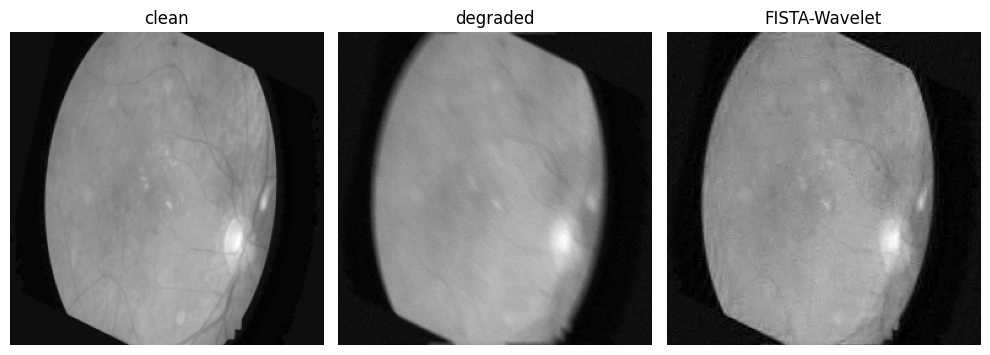

In [4]:
import matplotlib.pyplot as plt
fw=Forward((IMG_SIZE,IMG_SIZE)); x=Xte[0]; y=degrade_det(fw,x,0.01,idx=0)
rows=[]
for lam in [0.001,0.002,0.005,0.01,0.02]:
    r=fista_wavelet(y,fw,lam,200); rows.append((lam,psnr(x,r),ssim(x,r)))
    print(f"lam={lam:<6} PSNR {psnr(x,r):.2f} SSIM {ssim(x,r):.3f}")
best=max(rows,key=lambda t:t[1]); print("best lambda:",best[0])
rec=fista_wavelet(y,fw,best[0],300)
fig,ax=plt.subplots(1,3,figsize=(10,3.6))
for a,im,tt in zip(ax,[x,y,rec],["clean","degraded","FISTA-Wavelet"]):
    a.imshow(im,cmap="gray");a.set_title(tt);a.axis("off")
plt.tight_layout();plt.show()

### Full test set (save CSVs locally; Drive stays zip-only)

In [5]:
import pandas as pd
def run_fista(lam, sigma, n=None):
    fw=Forward((IMG_SIZE,IMG_SIZE)); ps=[];ss=[]
    imgs=Xte if n is None else Xte[:n]
    for i,x in enumerate(imgs):
        y=degrade_det(fw,x,sigma,idx=i); r=fista_wavelet(y,fw,lam,300)
        ps.append(psnr(x,r)); ss.append(ssim(x,r))
    return pd.DataFrame({"method":["fista"],"sigma":[sigma],
        "psnr_mean":[np.mean(ps)],"ssim_mean":[np.mean(ss)],"lambda":[lam]})
# Quick check on 20 images: print(run_fista(best[0], 0.01, n=20))
# Save locally (download or copy to Drive yourself if you want to share):
# import os; os.makedirs("Output/metrics",exist_ok=True)
# run_fista(best[0],0.01).to_csv("Output/metrics/fista_sigma0.01.csv",index=False)

## Full evaluation (tune on val, report on all 400 test)
Saves per-σ CSVs to Drive so a long (~1h) run survives a disconnect.

In [6]:
# Results persist to Drive (tiny CSVs). This is the ONLY extra thing on Drive
# besides the zip — necessary so a long run survives a disconnect.
import os, pandas as pd
OUT_METRICS = f"{DRIVE}/Output/metrics"
OUT_FIG     = f"{DRIVE}/Output/figures"
os.makedirs(OUT_METRICS, exist_ok=True); os.makedirs(OUT_FIG, exist_ok=True)
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x

In [7]:
LAMBDAS = [0.001, 0.002, 0.005, 0.01, 0.02]
N_TUNE  = 40   # validation images used only to pick lambda

def _scores(method, imgs, fw, sigma, lam):
    ps=[]; ss=[]
    for i,x in enumerate(imgs):
        y=degrade_det(fw,x,sigma,idx=i); r=method(y,fw,lam)
        ps.append(psnr(x,r)); ss.append(ssim(x,r))
    return np.mean(ps), np.std(ps), np.mean(ss), np.std(ss)

fw = Forward((IMG_SIZE,IMG_SIZE))
fmethod = lambda y,fw,lam: fista_wavelet(y,fw,lam,300)

# ---------- Stage 1: tune lambda on validation ----------
tune_rows=[]
for sigma in NOISE_LEVELS:
    best_p=(None,-1); best_s=(None,-1)
    for lam in LAMBDAS:
        pm,_,sm,_ = _scores(fmethod, Xva[:N_TUNE], fw, sigma, lam)
        tune_rows.append({"sigma":sigma,"lambda":lam,"psnr":pm,"ssim":sm})
        if pm>best_p[1]: best_p=(lam,pm)
        if sm>best_s[1]: best_s=(lam,sm)
    print(f"sigma={sigma}: best-PSNR lam={best_p[0]} ({best_p[1]:.2f}) | best-SSIM lam={best_s[0]} ({best_s[1]:.3f})")
tune_df=pd.DataFrame(tune_rows); tune_df.to_csv(f"{OUT_METRICS}/fista_tuning.csv",index=False)

# choose lambda per sigma (SSIM-based: medical images favor structure; change if you prefer PSNR)
chosen = {s: tune_df[tune_df.sigma==s].sort_values("ssim").iloc[-1]["lambda"] for s in NOISE_LEVELS}
print("chosen lambdas (SSIM):", chosen)

sigma=0.005: best-PSNR lam=0.001 (37.44) | best-SSIM lam=0.002 (0.925)
sigma=0.01: best-PSNR lam=0.002 (34.56) | best-SSIM lam=0.005 (0.881)
sigma=0.05: best-PSNR lam=0.02 (28.90) | best-SSIM lam=0.02 (0.561)
sigma=0.1: best-PSNR lam=0.02 (20.53) | best-SSIM lam=0.02 (0.186)
chosen lambdas (SSIM): {0.005: np.float64(0.002), 0.01: np.float64(0.005), 0.05: np.float64(0.02), 0.1: np.float64(0.02)}


In [5]:
import os, pandas as pd
final=[]
for sigma in NOISE_LEVELS:
    out_path = f"{OUT_METRICS}/fista_sigma{sigma}.csv"
    if os.path.exists(out_path):                 # già fatto -> salta
        print(f"sigma={sigma} già salvato, salto")
        final.append(pd.read_csv(out_path).iloc[0].to_dict())
        continue
    lam=float(chosen[sigma])
    pm,psd,sm,ssd = _scores(fmethod, Xte, fw, sigma, lam)
    row={"method":"fista","sigma":sigma,"lambda":lam,
         "psnr_mean":pm,"psnr_std":psd,"ssim_mean":sm,"ssim_std":ssd}
    final.append(row)
    pd.DataFrame([row]).to_csv(out_path, index=False)
    print(f"sigma={sigma}  PSNR {pm:.2f}±{psd:.2f}  SSIM {sm:.3f}±{ssd:.3f}  (lam={lam})")
pd.DataFrame(final).to_csv(f"{OUT_METRICS}/fista_all.csv", index=False)
print("fatto")

NameError: name 'NOISE_LEVELS' is not defined